# Task 1 [10 points]
 Apply BFS and DFS on trees and graphs. You can use simple examples for
your

---



**(I) Implementation of BFS and DFS on Tree**

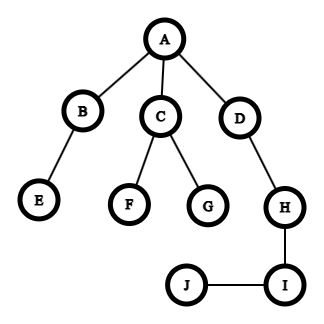

---



**Implementation of BFS**

In [ ]:
# BFS
graph = {
    'A': ['B', 'C', 'D'],
    'B': ['E'],
    'C': ['F', 'G'],
    'D': ['H'],
    'E': [],
    'F': [],
    'G': [],
    'H': ['I'],
    'I': ['J'],
    'J': []
}
from collections import deque

def bfs(graph, start):
    visited = set()
    queue = deque([start])

    visited.add(start)

    while queue:
        node = queue.popleft()
        print(node, end=" ")

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

# Run BFS
print("BFS Traversal:")
bfs(graph, 'A')

BFS Traversal:
A B C D E F G H I J 

**Implementation of DFS**





In [ ]:
graph = {
    'A': ['B', 'C', 'D'],
    'B': ['E'],
    'C': ['F', 'G'],
    'D': ['H'],
    'E': [],
    'F': [],
    'G': [],
    'H': ['I'],
    'I': ['J'],
    'J': []
}
def dfs(graph, node, visited):
    if node not in visited:
        print(node, end=" ")
        visited.add(node)

        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

# Run DFS
print("\nDFS Traversal:")
dfs(graph, 'A', set())


DFS Traversal:
A B E C F G D H I J 

**(II) Implementation of BFS and DFS on Graph**

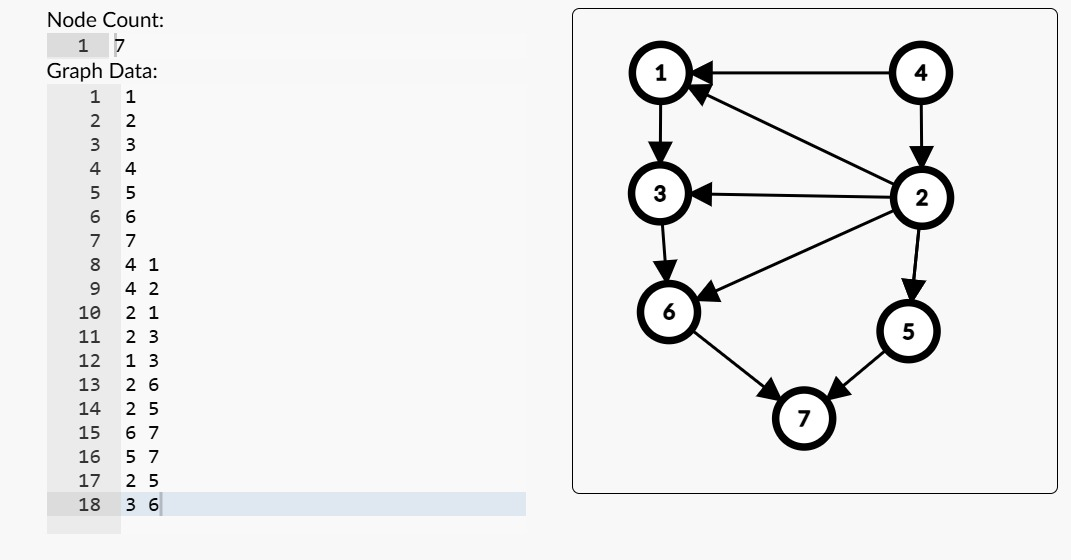

---



**(I) Implementation of BFS**

In [ ]:
graph = {
    1: [3],
    2: [1, 3, 6, 5],
    3: [6],
    4: [1, 2],
    5: [7],
    6: [7],
    7: []
}
from collections import deque

def bfs(graph, start):
    visited = set()
    queue = deque([start])

    visited.add(start)

    while queue:
        node = queue.popleft()
        print(node, end=" ")

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

# Run BFS (start from 4)
print("BFS Traversal:")
bfs(graph, 4)

BFS Traversal:
4 1 2 3 6 5 7 

**(II) Implementation of DFS**

In [ ]:
graph = {
    1: [3],
    2: [1, 3, 6, 5],
    3: [6],
    4: [1, 2],
    5: [7],
    6: [7],
    7: []
}
def dfs(graph, node, visited):
    if node not in visited:
        print(node, end=" ")
        visited.add(node)

        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

# Run DFS (start from 4)
print("\nDFS Traversal:")
dfs(graph, 4, set())


DFS Traversal:
4 1 3 6 7 2 5 

# Task 2 [10 points]
1. Generate random and unique numbers of ranges 1000,40,000,80,000,200,000 and
1,000,000. So now you have 5 sets of inputs, build the tree for each sets (each set has its
own list)
2. Apply BFS and DFS on each sets and calculate the time taken for the execution to find
that goal through BFS and DFS.
3. Goal should be lis[total_len – 220]
4. Make a data frame for your results as shown below.
5. Finally plot the bar chart of the time taken by each search for example (on X-axis the data
will be 1000,40,000,80,000,200,000 and 1,000,000.) and on the Y axis the data will be
the seconds it took while searching.

**Solution**

---



      Size  BFS Time  DFS Time
0     1000  0.000418  0.000304
1    40000  0.028931  0.025306
2    80000  0.067887  0.060292
3   200000  0.112665  0.117200
4  1000000  0.611945  0.600155


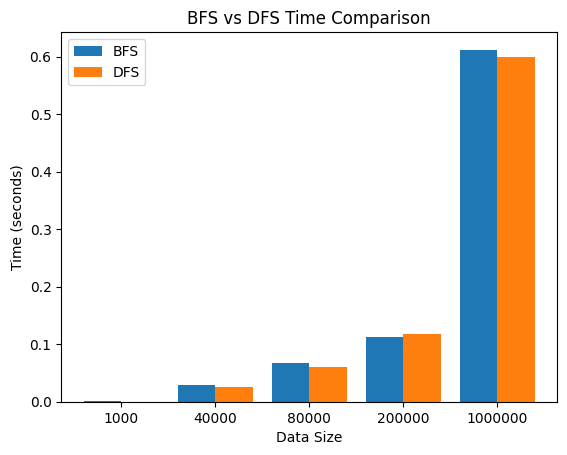

In [ ]:
import random
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt


sizes = [1000, 40000, 80000, 200000, 1000000]
datasets = {}

for size in sizes:
    datasets[size] = random.sample(range(size * 10), size)

def build_graph(lst):
    graph = {}
    for i in range(len(lst) - 1):
        graph[lst[i]] = [lst[i + 1]]
    graph[lst[-1]] = []
    return graph

# BFS
def BFS(graph, start, goal):
    visited = set()
    q = deque([start])

    while q:
        node = q.popleft()
        if node == goal:
            return True
        if node not in visited:
            visited.add(node)
            q.extend(graph[node])
    return False

# DFS
def DFS(graph, start, goal):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()
        if node == goal:
            return True
        if node not in visited:
            visited.add(node)
            stack.extend(graph[node])
    return False

def measure_time(func, graph, start, goal, repeat=3):
    total = 0
    for _ in range(repeat):
        start_time = time.perf_counter()
        func(graph, start, goal)
        total += time.perf_counter() - start_time
    return total / repeat

results = []

for size in sizes:
    lst = datasets[size]
    graph = build_graph(lst)

    start = lst[0]
    goal = lst[len(lst) - 220]

    bfs_time = measure_time(BFS, graph, start, goal)
    dfs_time = measure_time(DFS, graph, start, goal)

    results.append([size, bfs_time, dfs_time])

df = pd.DataFrame(results, columns=["Size", "BFS Time", "DFS Time"])
pd.set_option('display.float_format', '{:.6f}'.format)

print(df)

x = range(len(df["Size"]))
width = 0.4

plt.figure()

plt.bar([i - width/2 for i in x], df["BFS Time"], width, label="BFS")
plt.bar([i + width/2 for i in x], df["DFS Time"], width, label="DFS")

plt.xlabel("Data Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Time Comparison")

plt.xticks(x, df["Size"])
plt.legend()

plt.show()

# Task 3 [10 points]
Imagine you're a tourist in Pakistan, and you want to travel from Islamabad to Karachi. You
want to find the shortest route in terms of the number of cities you need to travel through. The
cities are connected through highways, and your goal is to find the shortest path using BFS.
Cities and Their Connections (Graph):
You will use the following cities and their connections for this scenario:
* Islamabad is connected to Rawalpindi, Lahore, and Peshawar.
* Rawalpindi is connected to Islamabad, Peshawar, and Quetta.
* Peshawar is connected to Islamabad, Rawalpindi, and Quetta.
* Lahore is connected to Islamabad, Multan, and Quetta.
* Multan is connected to Lahore, Karachi, and Quetta.
* Quetta is connected to Rawalpindi, Peshawar, Multan, and Karachi.
* Karachi is connected to Multan and Quetta.

**Answer**

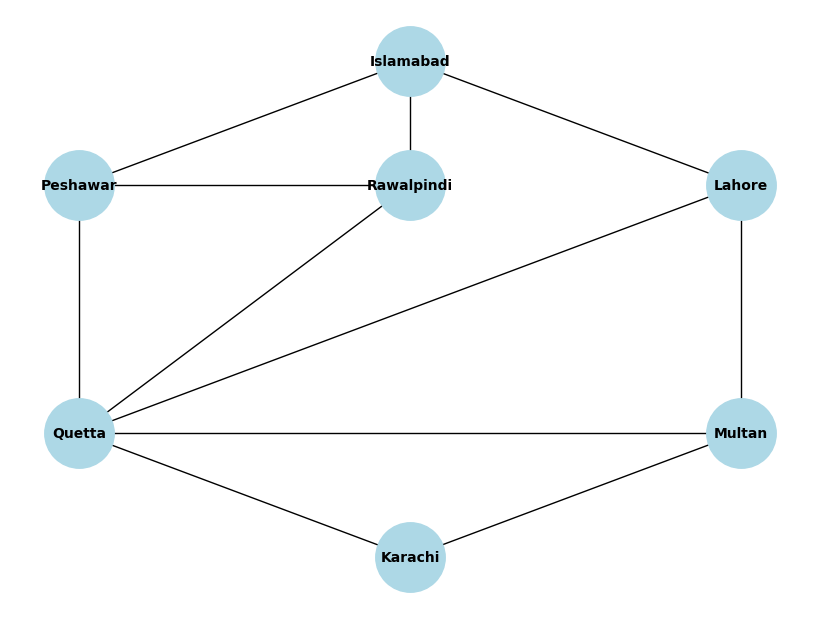

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Add edges
edges = [
    ("Islamabad","Rawalpindi"),
    ("Islamabad","Lahore"),
    ("Islamabad","Peshawar"),
    ("Rawalpindi","Peshawar"),
    ("Rawalpindi","Quetta"),
    ("Peshawar","Quetta"),
    ("Lahore","Multan"),
    ("Lahore","Quetta"),
    ("Multan","Karachi"),
    ("Multan","Quetta"),
    ("Quetta","Karachi")
]

G.add_edges_from(edges)

pos = {
    "Islamabad": (0, 2),
    "Rawalpindi": (0, 1),
    "Peshawar": (-2, 1),
    "Lahore": (2, 1),
    "Quetta": (-2, -1),
    "Multan": (2, -1),
    "Karachi": (0, -2)
}

plt.figure(figsize=(8,6))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    edge_color="black"
)

plt.savefig("graph.png")
plt.show()

**Implementation of BFS**

In [7]:
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def bfs_shortest_path(start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return None


start_city = "Islamabad"
goal_city = "Karachi"

path = bfs_shortest_path(start_city, goal_city)

print("Shortest Path from Islamabad to Karachi:")
print(" → ".join(path))

Shortest Path from Islamabad to Karachi:
Islamabad → Rawalpindi → Quetta → Karachi
